# Desarrollo de laboratorio 2 

**Nombre:** Sebastian David Chaparro Sánchez

In [9]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar matplotlib para mostrar gráficos dentro del cuaderno
%matplotlib inline

# Cargar el dataset (ignora la primera columna sin nombre que sirve de índice)
file_path = "./laptop_pricing_dataset_mod1.csv"
df = pd.read_csv(file_path, index_col=0)

# Mostrar las primeras 5 filas
print("--- Primeras filas del Dataset ---")
print(df.head())

# Mostrar la estructura general y tipos de datos iniciales
print("\n--- Información General ---")
df.info()

# Mostrar descripción estadística resumida
print("\n--- Descripción Estadística ---")
print(df.describe(include='all'))

--- Primeras filas del Dataset ---
  Manufacturer  Category     Screen  GPU  OS  CPU_core  Screen_Size_cm  \
0         Acer         4  IPS Panel    2   1         5          35.560   
1         Dell         3    Full HD    1   1         3          39.624   
2         Dell         3    Full HD    1   1         7          39.624   
3         Dell         4  IPS Panel    2   1         5          33.782   
4           HP         4    Full HD    2   1         7          39.624   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0            1.6       8             256       1.60    978  
1            2.0       4             256       2.20    634  
2            2.7       8             256       2.20    946  
3            1.6       8             128       1.22   1244  
4            1.8       8             256       1.91    837  

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null C

## Tarea 1: Tratamiento de Valores Faltantes (Missing Values)
### Objetivo

Identificar qué columnas contienen valores nulos y estandarizar su representación. Algunos valores faltantes pueden estar marcados con caracteres como "?" en lugar de estar completamente vacíos.

### Resolución

1. Reemplazamos cualquier ocurrencia de "?" por el valor nulo oficial de NumPy (np.nan).
2. Contamos la cantidad de valores nulos por cada columna.


In [10]:
# Paso 1: Reemplazar los valores "?" por NaN nulos estándar
df.replace('?', np.nan, inplace=True)

# Paso 2: Contar y visualizar cuántos valores nulos hay por columna
null_counts = df.isnull().sum()
print("Cantidad de valores faltantes por columna:")
print(null_counts[null_counts > 0])

Cantidad de valores faltantes por columna:
Screen_Size_cm    4
Weight_kg         5
dtype: int64


## Tarea 2: Reemplazo de Valores Faltantes (Imputación)
### Objetivo
Imputar (rellenar) los valores nulos detectados utilizando estrategias adecuadas según la naturaleza del dato:
*   **Datos continuos (numéricos):** Reemplazar con el valor medio (promedio).
*   **Datos categóricos:** Reemplazar con el valor más frecuente (moda).

### Resolución
De la inspección de la **Tarea 1**, se observa que faltan valores en las columnas `Weight_kg` (continuo) y `Screen_Size_cm` (categórico en el contexto del tamaño físico estándar de la pantalla).

In [11]:
# 1. Imputación para datos continuos (Weight_kg)
# Calculamos la media de la columna convirtiéndola temporalmente a float
avg_weight = df['Weight_kg'].astype('float').mean(axis=0)
print(f"Media calculada para Weight_kg: {avg_weight:.3f}")

# CORREGIDO: Asignación directa sin 'inplace=True'
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)


# 2. Imputación para datos categóricos (Screen_Size_cm)
# Encontramos el valor más frecuente (la moda) utilizando idxmax() en value_counts()
most_frequent_screen = df['Screen_Size_cm'].value_counts().idxmax()
print(f"Valor más frecuente en Screen_Size_cm: {most_frequent_screen}")

# CORREGIDO: Asignación directa sin 'inplace=True'
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, most_frequent_screen)


# Verificar que no queden valores nulos en el DataFrame
print("\nValores nulos restantes en el dataset:", df.isnull().sum().sum())

Media calculada para Weight_kg: 1.862
Valor más frecuente en Screen_Size_cm: 39.624

Valores nulos restantes en el dataset: 0


## Tarea 3: Corregir Tipos de Datos
### Objetivo
Asegurarse de que las columnas numéricas que tienen números decimales no estén registradas con el tipo de dato genérico `object` (lo cual ocurre habitualmente cuando el archivo contenía textos o caracteres especiales antes de limpiarse).

### Resolución
Convertiremos las columnas `Weight_kg` y `Screen_Size_cm` a tipo flotante (`float`).

In [12]:
# Convertir las dos columnas a tipo numérico de punto flotante (float)
df[['Weight_kg', 'Screen_Size_cm']] = df[['Weight_kg', 'Screen_Size_cm']].astype('float')

# Validar los tipos de datos actualizados en el DataFrame
print(df.dtypes[['Weight_kg', 'Screen_Size_cm']])

Weight_kg         float64
Screen_Size_cm    float64
dtype: object


## Tarea 4: Estandarización de Datos y Normalización
### Objetivo
1.  **Estandarizar unidades de medida:** 
    *   Convertir `Screen_Size_cm` (centímetros) a pulgadas utilizando el factor de conversión `1 pulgada = 2.54 cm` y renombrar la columna a `Screen_Size_inch`.
    *   Convertir `Weight_kg` (kilogramos) a libras utilizando el factor de conversión `1 kg = 2.205 libras` y renombrar la columna a `Weight_lbs`.
2.  **Normalización de variables:**
    *   Normalizar la variable continua `CPU_frequency` respecto a su valor máximo, de forma que el rango quede escalado entre 0 y 1.

In [13]:
# 1. Estandarizar Screen_Size_cm a Pulgadas
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54
df.rename(columns={'Screen_Size_cm': 'Screen_Size_inch'}, inplace=True)

# 2. Estandarizar Weight_kg a Libras
df['Weight_kg'] = df['Weight_kg'] * 2.205
df.rename(columns={'Weight_kg': 'Weight_lbs'}, inplace=True)

# 3. Normalizar la columna CPU_frequency respecto a su máximo
max_cpu_freq = df['CPU_frequency'].max()
df['CPU_frequency'] = df['CPU_frequency'] / max_cpu_freq

# Ver una muestra del DataFrame para verificar los cambios
print(df[['Screen_Size_inch', 'Weight_lbs', 'CPU_frequency']].head())

   Screen_Size_inch  Weight_lbs  CPU_frequency
0              14.0     3.52800       0.551724
1              15.6     4.85100       0.689655
2              15.6     4.85100       0.931034
3              13.3     2.69010       0.551724
4              15.6     4.21155       0.620690


## Tarea 5: Agrupamiento de Datos (Binning)
### Objetivo
Dividir los valores continuos de una variable (en este caso `Price`) en un conjunto pequeño de categorías discretas o "contenedores" (bins) para simplificar su análisis. Crearemos tres rangos de precios llamados: `'Bajo'`, `'Medio'` y `'Alto'`.

### Resolución
1.  Creamos los intervalos uniformes con `np.linspace`.
2.  Agrupamos los datos usando `pd.cut` en la columna `"Agrupamiento de precios"`.
3.  Graficamos la distribución resultante usando un gráfico de barras.

Puntos de corte generados para los bins: [ 527.         1621.33333333 2715.66666667 3810.        ]

Recuento por categoría de precio:
Agrupamiento de precios
Bajo     160
Medio     72
Alto       6
Name: count, dtype: int64


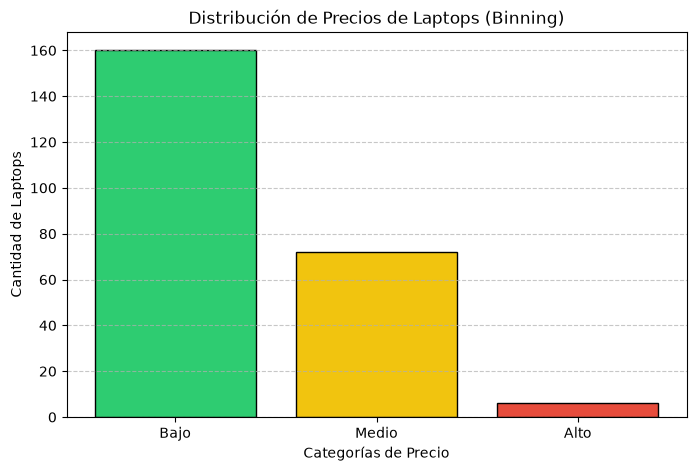

In [14]:
# Paso 1: Generar 4 puntos de corte equidistantes (para obtener 3 rangos)
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
print("Puntos de corte generados para los bins:", bins)

# Paso 2: Definir las etiquetas de los rangos
group_names = ['Bajo', 'Medio', 'Alto']

# Paso 3: Aplicar el corte en la columna Price
df['Agrupamiento de precios'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)

# Paso 4: Mostrar el recuento de elementos por rango
print("\nRecuento por categoría de precio:")
print(df['Agrupamiento de precios'].value_counts())

# Paso 5: Graficar la distribución usando matplotlib
plt.figure(figsize=(8, 5))
plt.bar(group_names, df['Agrupamiento de precios'].value_counts(), color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black')
plt.xlabel('Categorías de Precio')
plt.ylabel('Cantidad de Laptops')
plt.title('Distribución de Precios de Laptops (Binning)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Tarea 6: Variables Ficticias o Indicadoras (One-Hot Encoding)
### Objetivo
Convertir una columna de texto categórica (`Screen`) en múltiples columnas binarias (`0` o `1`) representativas para que puedan ser utilizadas en modelos matemáticos y algoritmos de Machine Learning.

En el conjunto de datos original, la columna `Screen` contiene dos valores únicos: `"IPS Panel"` y `"Full HD"`.

### Resolución
1.  Generamos las variables indicadoras utilizando `pd.get_dummies()`.
2.  Renombramos las columnas según las instrucciones (`Pantalla-IPS_panel` y `Pantalla-Full_HD`).
3.  Concatenamos las columnas binarias al DataFrame principal y eliminamos la columna de texto original.
4.  Exportamos el DataFrame final limpio como `clean_df.csv`.

In [15]:
# Paso 1: Generar las columnas indicadoras (convertidas a enteros 0 y 1)
dummy_screen = pd.get_dummies(df['Screen'], dtype=int)

# Paso 2: Renombrar las columnas generadas
dummy_screen.rename(columns={
    'IPS Panel': 'Pantalla-IPS_panel',
    'Full HD': 'Pantalla-Full_HD'
}, inplace=True)

# Paso 3: Concatenar las nuevas columnas ficticias al DataFrame principal
df = pd.concat([df, dummy_screen], axis=1)

# Paso 4: Eliminar la columna categórica original 'Screen'
df.drop('Screen', axis=1, inplace=True)

# Paso 5: Guardar el dataset limpio final en un archivo CSV
output_csv = "clean_df.csv"
df.to_csv(output_csv, index=False)

print(f"El dataset limpio ha sido guardado exitosamente como '{output_csv}'")
print("\nColumnas finales en el DataFrame preprocesado:")
print(df.columns.tolist()[:15]) # Muestra las primeras 15 columnas

El dataset limpio ha sido guardado exitosamente como 'clean_df.csv'

Columnas finales en el DataFrame preprocesado:
['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_lbs', 'Price', 'Agrupamiento de precios', 'Pantalla-Full_HD', 'Pantalla-IPS_panel']
